<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_3D_Sound_Wave_Simulation_with_CuPy_K3D_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!apt-get -qq update && apt-get -qq install -y openmpi-bin libopenmpi-dev
!pip install -q "k3d==2.18.1" trimesh "cupy-cuda12x>=13.0,<14" ipywidgets

# Enable Colab widget support.
from google.colab import output
output.enable_custom_widget_manager()

In [3]:
"""Adaptive GPU 3D acoustics with topology-guided Metropolis-Hastings.

This Google Colab script simulates relative acoustic pressure from two
disc-shaped sources inside a three-dimensional Cartesian box. CuPy performs
all time-domain field evolution on the GPU. An implicit six-neighbor voxel
graph drives a Metropolis-Hastings sampler that identifies dynamically
important wavefront regions. Those regions receive a blended fourth-order
spatial correction, evaluated either by adjacency gathers or by a GPU CSR
sparse operator selected automatically from the current workload.

The Metropolis-Hastings process controls computational attention only. The
acoustic field itself evolves deterministically from a finite-difference wave
equation, which avoids introducing Monte Carlo noise into the pressure field.
K3D renders a transparent, signed three-dimensional pressure volume over time.
"""

import functools
import gc
import http.server
import math
import socketserver
import threading
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import cupy as cp
import cupyx.scipy.sparse as cpx_sparse
import k3d
import numpy as np

try:
    from google.colab import output as colab_output
except ImportError:
    colab_output = None


# =============================================================================
# Control knobs
# =============================================================================

RANDOM_SEED = 17

BOX_SIZE_M = (6.0, 4.0, 3.0)
SPEED_OF_SOUND_M_S = 343.0

# Sound source parameters
SOURCE_SPECS = (
    {
        "center_m": (0.65, 1.35, 1.50),
        "radius_m": 0.28,
        "frequency_hz": 650.0, # Default is set to 650 Hz
        "phase_rad": 0.0,
        "amplitude": 1.0,
        "normal_axis": "x",
    },
    {
        "center_m": (0.65, 2.65, 1.50),
        "radius_m": 0.28,
        "frequency_hz": 675.0, # Default is set to 820 Hz
        "phase_rad": 0.55 * math.pi,
        "amplitude": 1.0,
        "normal_axis": "x",
    },
)
SOURCE_RAMP_CYCLES = 2.0
SOURCE_COUPLING = 0.38

BOUNDARY_MODE = "sponge"  # "sponge" or "rigid"
SPONGE_CELLS = 14
SPONGE_STRENGTH = 0.085
SPONGE_POWER = 2.4

SOLVER_POLICY = "auto"  # "auto", "dense2", "dense4", or "hybrid"
AUTO_MANAGE = True

GRID_SPACING_M = None
SIM_DURATION_S = None
CFL_SAFETY = 0.92

AUTO_POINTS_PER_WAVELENGTH_MIN = 10.5
AUTO_POINTS_PER_WAVELENGTH_MAX = 13.0
AUTO_MAX_GRID_VOXELS = 2_000_000
AUTO_GPU_MEMORY_FRACTION = 0.34
AUTO_ESTIMATED_BYTES_PER_VOXEL = 96.0
AUTO_DOMAIN_TRAVERSALS = 2.25
AUTO_MIN_SOURCE_CYCLES = 10.0

ADAPTIVE_HIGH_ORDER = True
DENSE_FOURTH_ORDER_MAX_VOXELS = 260_000
ACTIVE_FRACTION = None
ACTIVE_FRACTION_MIN = 0.055
ACTIVE_FRACTION_MAX = 0.16
ADAPT_INTERVAL_STEPS = None
MH_WALKERS = None
MH_SWEEPS = None
MH_TARGET_FLOOR = 2.0e-4
MH_BETA = 2.0
MH_VISIT_WEIGHT = 0.24
REFINEMENT_MIN_BLEND = 0.30

SPARSE_POLICY = "auto"  # Default: self-activating GPU CSR refinement.
SPARSE_MIN_GRID_VOXELS = 450_000
SPARSE_MIN_ACTIVE_CELLS = 18_000
SPARSE_MAX_ACTIVE_FRACTION = 0.22
SPARSE_MAX_NNZ = 3_500_000

TARGET_VIS_FRAMES = 64
MAX_VIS_FRAMES = 72
MAX_VIS_VOXELS_PER_FRAME = 180_000
MAX_VIS_TOTAL_RAW_MIB = 48.0
VIS_GAIN = 1.70
VIS_SCALE_PERCENTILE = 99.5
VIS_SCALE_FLOOR_FRACTION = 0.08
VIS_DROP_LEADING_QUIET_FRAMES = True
VIS_QUIET_FRAME_FRACTION = 0.012
VIS_MIN_GLOBAL_PEAK = 1.0e-8
VIS_ALPHA_COEF = 9.0
VIS_VOLUME_SAMPLES = 256.0
VIS_RAY_SAMPLES = 24
VIS_FPS = 18.0
VIS_COMPRESSION_LEVEL = 2
AUTO_PLAY = True

K3D_DISPLAY_MODE = "auto"  # "auto", "widget", or "standalone"
K3D_WIDGET_MAX_RAW_MIB = 24.0
K3D_IFRAME_HEIGHT = 760
K3D_SNAPSHOT_COMPRESSION_LEVEL = 6
K3D_HIDE_GRID_LABELS = True
K3D_CAMERA_UP_AXIS = "z"
K3D_AUTO_CAMERA = True
K3D_CAMERA_DISTANCE_FACTOR = 1.55
K3D_CAMERA_SOURCE_BIAS = 0.20
K3D_SOURCE_DISC_SEGMENTS_MIN = 36
K3D_SOURCE_DISC_SEGMENTS_MAX = 144

SHOW_SOURCE_DISCS = True
SOURCE_DISC_OPACITY = 1.0
WRITE_STANDALONE_HTML = False
STANDALONE_HTML_PATH = "/content/topological_mh_acoustics.html"

CHECK_NUMERICAL_HEALTH = True
HEALTH_CHECK_INTERVAL_STEPS = None
HEALTH_MAX_ABS_PRESSURE = 1.0e6
PRINT_FRAME_DIAGNOSTICS = True
PRINT_PROGRESS = True

_K3D_HTTP_SERVERS: list[socketserver.TCPServer] = []


# =============================================================================
# Runtime data structures
# =============================================================================


@dataclass(frozen=True)
class RuntimeConfig:
    """Resolved numerical and adaptive parameters."""

    shape: tuple[int, int, int]
    spacing_m: tuple[float, float, float]
    dt_s: float
    steps: int
    duration_s: float
    points_per_wavelength: float
    requested_points_per_wavelength: float
    adapt_interval_steps: int
    active_fraction_base: float
    mh_walkers: int
    mh_sweeps: int
    snapshot_stride: int
    visualization_stride: int
    solver_mode: str
    free_gpu_bytes: int
    total_gpu_bytes: int

    @property
    def voxel_count(self) -> int:
        """Return the number of grid voxels."""
        return int(np.prod(self.shape))


@dataclass
class SourceNodes:
    """GPU-resident source support and source parameters."""

    indices: cp.ndarray
    weights: cp.ndarray
    frequency_hz: float
    phase_rad: float
    amplitude: float
    center_m: tuple[float, float, float]
    radius_m: float
    normal_axis: str


@dataclass
class RefinementState:
    """Active high-order refinement backend state."""

    active_indices: cp.ndarray
    blend_weights: cp.ndarray
    backend: str
    sparse_operator: Any | None = None
    neighbor_columns: cp.ndarray | None = None


# =============================================================================
# Automatic configuration
# =============================================================================


def validate_control_knobs() -> None:
    """Check user-facing controls before allocating large GPU arrays."""
    if not SOURCE_SPECS:
        raise ValueError("SOURCE_SPECS must contain at least one source.")

    if len(BOX_SIZE_M) != 3 or any(
        not math.isfinite(float(length)) or float(length) <= 0.0
        for length in BOX_SIZE_M
    ):
        raise ValueError(
            "BOX_SIZE_M must contain three finite positive dimensions."
        )

    if not math.isfinite(SPEED_OF_SOUND_M_S) or SPEED_OF_SOUND_M_S <= 0.0:
        raise ValueError("SPEED_OF_SOUND_M_S must be finite and positive.")

    if SOLVER_POLICY.lower() not in {"auto", "dense2", "dense4", "hybrid"}:
        raise ValueError(
            "SOLVER_POLICY must be 'auto', 'dense2', 'dense4', or 'hybrid'."
        )

    if SPARSE_POLICY.lower() not in {"auto", "on", "off"}:
        raise ValueError("SPARSE_POLICY must be 'auto', 'on', or 'off'.")

    if not 0.0 < CFL_SAFETY <= 0.98:
        raise ValueError("CFL_SAFETY must lie in the interval (0, 0.98].")

    if GRID_SPACING_M is not None and (
        not math.isfinite(float(GRID_SPACING_M)) or GRID_SPACING_M <= 0.0
    ):
        raise ValueError("GRID_SPACING_M must be finite and positive or None.")

    if SIM_DURATION_S is not None and (
        not math.isfinite(float(SIM_DURATION_S)) or SIM_DURATION_S <= 0.0
    ):
        raise ValueError("SIM_DURATION_S must be finite and positive or None.")

    if AUTO_POINTS_PER_WAVELENGTH_MIN <= 0.0:
        raise ValueError("AUTO_POINTS_PER_WAVELENGTH_MIN must be positive.")

    if AUTO_POINTS_PER_WAVELENGTH_MAX < AUTO_POINTS_PER_WAVELENGTH_MIN:
        raise ValueError(
            "AUTO_POINTS_PER_WAVELENGTH_MAX must be at least the minimum."
        )

    if AUTO_MAX_GRID_VOXELS < 343:
        raise ValueError("AUTO_MAX_GRID_VOXELS must be at least 343.")

    if not 0.0 < AUTO_GPU_MEMORY_FRACTION <= 0.90:
        raise ValueError("AUTO_GPU_MEMORY_FRACTION must lie in (0, 0.90].")

    if AUTO_ESTIMATED_BYTES_PER_VOXEL <= 0.0:
        raise ValueError("AUTO_ESTIMATED_BYTES_PER_VOXEL must be positive.")

    if not 0.0 < ACTIVE_FRACTION_MIN <= ACTIVE_FRACTION_MAX < 1.0:
        raise ValueError(
            "ACTIVE_FRACTION_MIN and ACTIVE_FRACTION_MAX must satisfy "
            "0 < min <= max < 1."
        )

    if ACTIVE_FRACTION is not None and not 0.0 < ACTIVE_FRACTION < 1.0:
        raise ValueError("ACTIVE_FRACTION must lie in (0, 1) or be None.")

    if ADAPT_INTERVAL_STEPS is not None and ADAPT_INTERVAL_STEPS < 1:
        raise ValueError("ADAPT_INTERVAL_STEPS must be positive or None.")

    if MH_WALKERS is not None and MH_WALKERS < 1:
        raise ValueError("MH_WALKERS must be positive or None.")

    if MH_SWEEPS is not None and MH_SWEEPS < 1:
        raise ValueError("MH_SWEEPS must be positive or None.")

    if MH_TARGET_FLOOR <= 0.0 or MH_BETA <= 0.0:
        raise ValueError("MH_TARGET_FLOOR and MH_BETA must be positive.")

    if not 0.0 <= MH_VISIT_WEIGHT <= 1.0:
        raise ValueError("MH_VISIT_WEIGHT must lie in [0, 1].")

    if not 0.0 <= REFINEMENT_MIN_BLEND <= 1.0:
        raise ValueError("REFINEMENT_MIN_BLEND must lie in [0, 1].")

    if SPARSE_MIN_GRID_VOXELS < 1 or SPARSE_MIN_ACTIVE_CELLS < 1:
        raise ValueError("Sparse activation thresholds must be positive.")

    if not 0.0 < SPARSE_MAX_ACTIVE_FRACTION < 1.0:
        raise ValueError("SPARSE_MAX_ACTIVE_FRACTION must lie in (0, 1).")

    if SPARSE_MAX_NNZ < 13:
        raise ValueError("SPARSE_MAX_NNZ must be at least 13.")

    if TARGET_VIS_FRAMES < 1 or MAX_VIS_FRAMES < 1:
        raise ValueError("Visualization frame limits must be positive.")

    if MAX_VIS_VOXELS_PER_FRAME < 1:
        raise ValueError("MAX_VIS_VOXELS_PER_FRAME must be positive.")

    if MAX_VIS_TOTAL_RAW_MIB <= 0.0:
        raise ValueError("MAX_VIS_TOTAL_RAW_MIB must be positive.")

    if VIS_FPS <= 0.0 or VIS_ALPHA_COEF <= 0.0:
        raise ValueError("VIS_FPS and VIS_ALPHA_COEF must be positive.")

    if K3D_WIDGET_MAX_RAW_MIB <= 0.0 or K3D_IFRAME_HEIGHT < 200:
        raise ValueError(
            "K3D_WIDGET_MAX_RAW_MIB must be positive and "
            "K3D_IFRAME_HEIGHT must be at least 200."
        )

    if not 0.0 < VIS_SCALE_PERCENTILE <= 100.0:
        raise ValueError("VIS_SCALE_PERCENTILE must lie in (0, 100].")

    if not 0.0 < VIS_SCALE_FLOOR_FRACTION <= 1.0:
        raise ValueError("VIS_SCALE_FLOOR_FRACTION must lie in (0, 1].")

    if not 0.0 <= VIS_QUIET_FRAME_FRACTION < 1.0:
        raise ValueError("VIS_QUIET_FRAME_FRACTION must lie in [0, 1).")

    if VIS_MIN_GLOBAL_PEAK <= 0.0 or HEALTH_MAX_ABS_PRESSURE <= 0.0:
        raise ValueError(
            "VIS_MIN_GLOBAL_PEAK and HEALTH_MAX_ABS_PRESSURE must be positive."
        )

    if K3D_DISPLAY_MODE.lower() not in {"auto", "widget", "standalone"}:
        raise ValueError(
            "K3D_DISPLAY_MODE must be 'auto', 'widget', or 'standalone'."
        )

    if K3D_CAMERA_UP_AXIS.lower() not in {"x", "y", "z"}:
        raise ValueError("K3D_CAMERA_UP_AXIS must be 'x', 'y', or 'z'.")

    if K3D_CAMERA_DISTANCE_FACTOR <= 0.0:
        raise ValueError("K3D_CAMERA_DISTANCE_FACTOR must be positive.")

    if not 0.0 <= K3D_CAMERA_SOURCE_BIAS <= 1.0:
        raise ValueError("K3D_CAMERA_SOURCE_BIAS must lie in [0, 1].")

    if (
        K3D_SOURCE_DISC_SEGMENTS_MIN < 12
        or K3D_SOURCE_DISC_SEGMENTS_MAX < K3D_SOURCE_DISC_SEGMENTS_MIN
    ):
        raise ValueError(
            "K3D source-disc segment limits must satisfy "
            "12 <= min <= max."
        )

    required_source_keys = {
        "center_m",
        "radius_m",
        "frequency_hz",
        "phase_rad",
        "amplitude",
        "normal_axis",
    }

    for source_index, spec in enumerate(SOURCE_SPECS):
        missing = required_source_keys.difference(spec)
        if missing:
            missing_text = ", ".join(sorted(missing))
            raise ValueError(
                f"SOURCE_SPECS[{source_index}] is missing: {missing_text}."
            )

        center = tuple(float(value) for value in spec["center_m"])
        frequency_hz = float(spec["frequency_hz"])
        radius_m = float(spec["radius_m"])
        phase_rad = float(spec["phase_rad"])
        amplitude = float(spec["amplitude"])
        axis = str(spec["normal_axis"]).lower()

        if len(center) != 3 or not all(math.isfinite(value) for value in center):
            raise ValueError(
                f"SOURCE_SPECS[{source_index}] center_m must contain "
                "three finite coordinates."
            )
        if frequency_hz <= 0.0 or not math.isfinite(frequency_hz):
            raise ValueError(
                f"SOURCE_SPECS[{source_index}] frequency_hz must be finite "
                "and positive."
            )
        if radius_m <= 0.0 or not math.isfinite(radius_m):
            raise ValueError(
                f"SOURCE_SPECS[{source_index}] radius_m must be finite and "
                "positive."
            )
        if not math.isfinite(phase_rad) or not math.isfinite(amplitude):
            raise ValueError(
                f"SOURCE_SPECS[{source_index}] phase_rad and amplitude must "
                "be finite."
            )
        if axis not in {"x", "y", "z"}:
            raise ValueError(
                f"SOURCE_SPECS[{source_index}] normal_axis must be x, y, or z."
            )


def _grid_shape(
    box_size_m: tuple[float, float, float],
    nominal_spacing_m: float,
) -> tuple[int, int, int]:
    """Return a grid shape that exactly spans the requested box."""
    return tuple(
        max(7, int(math.ceil(length / nominal_spacing_m)) + 1)
        for length in box_size_m
    )


def _spacing_from_shape(
    box_size_m: tuple[float, float, float],
    shape: tuple[int, int, int],
) -> tuple[float, float, float]:
    """Return exact grid spacing for a box and node counts."""
    return tuple(
        length / float(count - 1)
        for length, count in zip(box_size_m, shape)
    )


def _resolved_points_per_wavelength(frequencies_hz: list[float]) -> float:
    """Choose a spatial sampling target from the source spectrum."""
    f_max = max(frequencies_hz)
    f_min = min(frequencies_hz)
    bandwidth_ratio = (f_max - f_min) / max(f_max, 1.0)
    frequency_load = np.clip(f_max / 2200.0, 0.0, 1.0)

    target = (
        AUTO_POINTS_PER_WAVELENGTH_MIN
        + 1.35 * frequency_load
        + 0.85 * bandwidth_ratio
    )
    return float(
        np.clip(
            target,
            AUTO_POINTS_PER_WAVELENGTH_MIN,
            AUTO_POINTS_PER_WAVELENGTH_MAX,
        )
    )


def _resolve_solver_mode(voxel_count: int) -> str:
    """Choose the deterministic or topology-guided spatial solver."""
    policy = SOLVER_POLICY.lower()

    if policy in {"dense2", "dense4", "hybrid"}:
        return policy
    if policy != "auto":
        raise ValueError(
            "SOLVER_POLICY must be 'auto', 'dense2', 'dense4', or 'hybrid'."
        )

    if not ADAPTIVE_HIGH_ORDER:
        return "dense2"
    if voxel_count <= DENSE_FOURTH_ORDER_MAX_VOXELS:
        return "dense4"
    return "hybrid"


def resolve_runtime_config() -> RuntimeConfig:
    """Resolve spatial, temporal, adaptive, and visualization scales."""
    validate_control_knobs()
    frequencies = [float(spec["frequency_hz"]) for spec in SOURCE_SPECS]
    f_max = max(frequencies)
    f_min = min(frequencies)

    free_bytes, total_bytes = cp.cuda.Device().mem_info

    requested_ppw = _resolved_points_per_wavelength(frequencies)
    wavelength_min = SPEED_OF_SOUND_M_S / f_max

    if GRID_SPACING_M is None:
        nominal_spacing = wavelength_min / requested_ppw
    else:
        nominal_spacing = float(GRID_SPACING_M)

    shape = _grid_shape(BOX_SIZE_M, nominal_spacing)
    requested_voxels = int(np.prod(shape))

    memory_limited_voxels = int(
        free_bytes
        * AUTO_GPU_MEMORY_FRACTION
        / AUTO_ESTIMATED_BYTES_PER_VOXEL
    )
    max_voxels = max(
        50_000,
        min(AUTO_MAX_GRID_VOXELS, memory_limited_voxels),
    )

    if AUTO_MANAGE and requested_voxels > max_voxels:
        scale = (requested_voxels / max_voxels) ** (1.0 / 3.0)
        nominal_spacing *= 1.025 * scale
        shape = _grid_shape(BOX_SIZE_M, nominal_spacing)

    spacing = _spacing_from_shape(BOX_SIZE_M, shape)
    voxel_count = int(np.prod(shape))
    actual_ppw = wavelength_min / max(spacing)
    solver_mode = _resolve_solver_mode(voxel_count)

    inv_sq_sum = sum(1.0 / (delta * delta) for delta in spacing)

    if solver_mode in {"dense4", "hybrid"}:
        dt_limit = (
            math.sqrt(3.0)
            / (2.0 * SPEED_OF_SOUND_M_S * math.sqrt(inv_sq_sum))
        )
    else:
        dt_limit = 1.0 / (
            SPEED_OF_SOUND_M_S * math.sqrt(inv_sq_sum)
        )

    dt_s = CFL_SAFETY * dt_limit

    if SIM_DURATION_S is None:
        diagonal = math.sqrt(sum(length * length for length in BOX_SIZE_M))
        travel_duration = (
            AUTO_DOMAIN_TRAVERSALS * diagonal / SPEED_OF_SOUND_M_S
        )
        cycle_duration = AUTO_MIN_SOURCE_CYCLES / f_min
        duration_s = max(travel_duration, cycle_duration)
    else:
        duration_s = float(SIM_DURATION_S)

    steps = max(1, int(math.ceil(duration_s / dt_s)))
    duration_s = steps * dt_s

    if ADAPT_INTERVAL_STEPS is None:
        scale_load = np.clip(
            math.log10(max(voxel_count, 10_000)) / 7.0,
            0.45,
            1.0,
        )
        adapt_interval = int(
            np.clip(round((0.00085 / dt_s) * scale_load), 8, 36)
        )
    else:
        adapt_interval = int(ADAPT_INTERVAL_STEPS)

    bandwidth_ratio = (f_max - f_min) / max(f_max, 1.0)
    if ACTIVE_FRACTION is None:
        size_factor = (500_000.0 / max(voxel_count, 1)) ** 0.075
        active_fraction = 0.115 * size_factor * (
            1.0 + 0.22 * bandwidth_ratio
        )
        active_fraction = float(
            np.clip(
                active_fraction,
                ACTIVE_FRACTION_MIN,
                ACTIVE_FRACTION_MAX,
            )
        )
    else:
        active_fraction = float(ACTIVE_FRACTION)

    if MH_WALKERS is None:
        walkers = int(
            np.clip(
                30.0 * math.sqrt(voxel_count),
                12_000,
                90_000,
            )
        )
    else:
        walkers = int(MH_WALKERS)

    if MH_SWEEPS is None:
        sweeps = 4 if voxel_count < 1_500_000 else 3
    else:
        sweeps = int(MH_SWEEPS)

    target_frames = min(TARGET_VIS_FRAMES, MAX_VIS_FRAMES)
    snapshot_stride = max(1, int(math.ceil(steps / target_frames)))
    estimated_frames = min(
        target_frames + 1,
        int(math.ceil(steps / snapshot_stride)) + 1,
    )

    visualization_stride = max(
        1,
        int(
            math.ceil(
                (voxel_count / MAX_VIS_VOXELS_PER_FRAME) ** (1.0 / 3.0)
            )
        ),
    )

    max_total_bytes = MAX_VIS_TOTAL_RAW_MIB * 2**20
    while True:
        displayed_shape = tuple(
            int(math.ceil((count - 1) / visualization_stride)) + 1
            for count in shape
        )
        displayed_voxels = int(np.prod(displayed_shape))
        estimated_payload = 4 * displayed_voxels * estimated_frames
        if estimated_payload <= max_total_bytes:
            break
        visualization_stride += 1

    return RuntimeConfig(
        shape=shape,
        spacing_m=spacing,
        dt_s=dt_s,
        steps=steps,
        duration_s=duration_s,
        points_per_wavelength=actual_ppw,
        requested_points_per_wavelength=requested_ppw,
        adapt_interval_steps=adapt_interval,
        active_fraction_base=active_fraction,
        mh_walkers=walkers,
        mh_sweeps=sweeps,
        snapshot_stride=snapshot_stride,
        visualization_stride=visualization_stride,
        solver_mode=solver_mode,
        free_gpu_bytes=int(free_bytes),
        total_gpu_bytes=int(total_bytes),
    )


# =============================================================================
# Geometry and boundary fields
# =============================================================================


def build_source_nodes(config: RuntimeConfig) -> list[SourceNodes]:
    """Rasterize disc sources into compact GPU index and weight arrays."""
    nx, ny, nz = config.shape
    dx, dy, dz = config.spacing_m
    sources: list[SourceNodes] = []

    for spec in SOURCE_SPECS:
        center = tuple(float(v) for v in spec["center_m"])
        radius = float(spec["radius_m"])
        axis = str(spec["normal_axis"]).lower()

        if not all(
            0.0 <= value <= limit
            for value, limit in zip(center, BOX_SIZE_M)
        ):
            raise ValueError(f"Source center {center} lies outside the box.")

        if radius <= 0.0:
            raise ValueError("Source radius must be positive.")

        if axis == "x":
            i = int(np.clip(round(center[0] / dx), 2, nx - 3))
            y = cp.arange(ny, dtype=cp.float32) * np.float32(dy)
            z = cp.arange(nz, dtype=cp.float32) * np.float32(dz)
            yy, zz = cp.meshgrid(y, z, indexing="ij")
            rr = cp.sqrt((yy - center[1]) ** 2 + (zz - center[2]) ** 2)
            mask = rr <= radius
            jj, kk = cp.nonzero(mask)
            indices = i * ny * nz + jj * nz + kk
            radial = rr[mask] / radius

        elif axis == "y":
            j = int(np.clip(round(center[1] / dy), 2, ny - 3))
            x = cp.arange(nx, dtype=cp.float32) * np.float32(dx)
            z = cp.arange(nz, dtype=cp.float32) * np.float32(dz)
            xx, zz = cp.meshgrid(x, z, indexing="ij")
            rr = cp.sqrt((xx - center[0]) ** 2 + (zz - center[2]) ** 2)
            mask = rr <= radius
            ii, kk = cp.nonzero(mask)
            indices = ii * ny * nz + j * nz + kk
            radial = rr[mask] / radius

        elif axis == "z":
            k = int(np.clip(round(center[2] / dz), 2, nz - 3))
            x = cp.arange(nx, dtype=cp.float32) * np.float32(dx)
            y = cp.arange(ny, dtype=cp.float32) * np.float32(dy)
            xx, yy = cp.meshgrid(x, y, indexing="ij")
            rr = cp.sqrt((xx - center[0]) ** 2 + (yy - center[1]) ** 2)
            mask = rr <= radius
            ii, jj = cp.nonzero(mask)
            indices = ii * ny * nz + jj * nz + k
            radial = rr[mask]

        else:
            raise ValueError("normal_axis must be 'x', 'y', or 'z'.")

        if indices.size == 0:
            raise ValueError(
                "A source disc contains no voxels. Increase its radius or "
                "refine the grid."
            )

        if axis == "z":
            radial = radial / radius

        weights = 0.5 * (
            1.0 + cp.cos(cp.pi * cp.clip(radial, 0.0, 1.0))
        )
        weights = weights.astype(cp.float32)
        indices = indices.astype(cp.int32)

        sources.append(
            SourceNodes(
                indices=indices,
                weights=weights,
                frequency_hz=float(spec["frequency_hz"]),
                phase_rad=float(spec["phase_rad"]),
                amplitude=float(spec["amplitude"]),
                center_m=center,
                radius_m=radius,
                normal_axis=axis,
            )
        )

    return sources


def build_sponge_damping(config: RuntimeConfig) -> cp.ndarray:
    """Return a smooth multiplicative damping field for open boundaries."""
    if BOUNDARY_MODE.lower() == "rigid":
        return cp.ones(config.shape, dtype=cp.float32)

    if BOUNDARY_MODE.lower() != "sponge":
        raise ValueError("BOUNDARY_MODE must be 'sponge' or 'rigid'.")

    nx, ny, nz = config.shape

    ix = cp.arange(nx, dtype=cp.float32)
    iy = cp.arange(ny, dtype=cp.float32)
    iz = cp.arange(nz, dtype=cp.float32)

    ix = cp.minimum(ix, nx - 1 - ix)[:, None, None]
    iy = cp.minimum(iy, ny - 1 - iy)[None, :, None]
    iz = cp.minimum(iz, nz - 1 - iz)[None, None, :]

    distance = cp.minimum(cp.minimum(ix, iy), iz)
    profile = cp.clip(
        (np.float32(SPONGE_CELLS) - distance)
        / np.float32(max(SPONGE_CELLS, 1)),
        0.0,
        1.0,
    )
    damping = cp.exp(
        -np.float32(SPONGE_STRENGTH)
        * profile ** np.float32(SPONGE_POWER)
    )
    return damping.astype(cp.float32)


def apply_rigid_boundaries(field: cp.ndarray) -> None:
    """Apply a simple zero-normal-gradient reflecting boundary."""
    field[0, :, :] = field[1, :, :]
    field[-1, :, :] = field[-2, :, :]
    field[:, 0, :] = field[:, 1, :]
    field[:, -1, :] = field[:, -2, :]
    field[:, :, 0] = field[:, :, 1]
    field[:, :, -1] = field[:, :, -2]


# =============================================================================
# Deterministic wave operators
# =============================================================================


def laplacian_second_order(
    field: cp.ndarray,
    output: cp.ndarray,
    spacing_m: tuple[float, float, float],
) -> None:
    """Evaluate a seven-point second-order Cartesian Laplacian."""
    dx, dy, dz = spacing_m
    inv_dx2 = np.float32(1.0 / (dx * dx))
    inv_dy2 = np.float32(1.0 / (dy * dy))
    inv_dz2 = np.float32(1.0 / (dz * dz))

    output.fill(0.0)
    core = output[1:-1, 1:-1, 1:-1]

    core[...] = (
        (
            field[2:, 1:-1, 1:-1]
            - 2.0 * field[1:-1, 1:-1, 1:-1]
            + field[:-2, 1:-1, 1:-1]
        )
        * inv_dx2
        + (
            field[1:-1, 2:, 1:-1]
            - 2.0 * field[1:-1, 1:-1, 1:-1]
            + field[1:-1, :-2, 1:-1]
        )
        * inv_dy2
        + (
            field[1:-1, 1:-1, 2:]
            - 2.0 * field[1:-1, 1:-1, 1:-1]
            + field[1:-1, 1:-1, :-2]
        )
        * inv_dz2
    )


def laplacian_fourth_order(
    field: cp.ndarray,
    output: cp.ndarray,
    spacing_m: tuple[float, float, float],
) -> None:
    """Evaluate a 13-point fourth-order Cartesian Laplacian."""
    dx, dy, dz = spacing_m
    inv_dx2 = np.float32(1.0 / (dx * dx))
    inv_dy2 = np.float32(1.0 / (dy * dy))
    inv_dz2 = np.float32(1.0 / (dz * dz))

    c0 = np.float32(-2.5)
    c1 = np.float32(4.0 / 3.0)
    c2 = np.float32(-1.0 / 12.0)

    laplacian_second_order(field, output, spacing_m)
    center = field[2:-2, 2:-2, 2:-2]
    core = output[2:-2, 2:-2, 2:-2]

    dxx = (
        c2 * field[:-4, 2:-2, 2:-2]
        + c1 * field[1:-3, 2:-2, 2:-2]
        + c0 * center
        + c1 * field[3:-1, 2:-2, 2:-2]
        + c2 * field[4:, 2:-2, 2:-2]
    ) * inv_dx2

    dyy = (
        c2 * field[2:-2, :-4, 2:-2]
        + c1 * field[2:-2, 1:-3, 2:-2]
        + c0 * center
        + c1 * field[2:-2, 3:-1, 2:-2]
        + c2 * field[2:-2, 4:, 2:-2]
    ) * inv_dy2

    dzz = (
        c2 * field[2:-2, 2:-2, :-4]
        + c1 * field[2:-2, 2:-2, 1:-3]
        + c0 * center
        + c1 * field[2:-2, 2:-2, 3:-1]
        + c2 * field[2:-2, 2:-2, 4:]
    ) * inv_dz2

    core[...] = dxx + dyy + dzz


def fourth_order_offsets_and_weights(
    config: RuntimeConfig,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Return flattened 13-point adjacency offsets and stencil weights."""
    _, ny, nz = config.shape
    dx, dy, dz = config.spacing_m
    plane = ny * nz

    offsets = cp.asarray(
        [
            0,
            -plane,
            plane,
            -2 * plane,
            2 * plane,
            -nz,
            nz,
            -2 * nz,
            2 * nz,
            -1,
            1,
            -2,
            2,
        ],
        dtype=cp.int32,
    )

    inv_dx2 = 1.0 / (dx * dx)
    inv_dy2 = 1.0 / (dy * dy)
    inv_dz2 = 1.0 / (dz * dz)

    center = -2.5 * (inv_dx2 + inv_dy2 + inv_dz2)
    weights = cp.asarray(
        [
            center,
            (4.0 / 3.0) * inv_dx2,
            (4.0 / 3.0) * inv_dx2,
            (-1.0 / 12.0) * inv_dx2,
            (-1.0 / 12.0) * inv_dx2,
            (4.0 / 3.0) * inv_dy2,
            (4.0 / 3.0) * inv_dy2,
            (-1.0 / 12.0) * inv_dy2,
            (-1.0 / 12.0) * inv_dy2,
            (4.0 / 3.0) * inv_dz2,
            (4.0 / 3.0) * inv_dz2,
            (-1.0 / 12.0) * inv_dz2,
            (-1.0 / 12.0) * inv_dz2,
        ],
        dtype=cp.float32,
    )
    return offsets, weights


# =============================================================================
# Topological Metropolis-Hastings adaptivity
# =============================================================================


def initialize_walkers(
    config: RuntimeConfig,
    sources: list[SourceNodes],
) -> cp.ndarray:
    """Initialize MH walkers near sources with a uniform exploratory fraction."""
    n_walkers = config.mh_walkers
    n_source = int(round(0.72 * n_walkers))
    n_uniform = n_walkers - n_source

    source_pool = cp.concatenate([source.indices for source in sources])
    source_choices = cp.random.randint(
        0,
        source_pool.size,
        size=n_source,
        dtype=cp.int32,
    )
    source_walkers = source_pool[source_choices]

    uniform_walkers = cp.random.randint(
        0,
        config.voxel_count,
        size=n_uniform,
        dtype=cp.int32,
    )

    return cp.concatenate([source_walkers, uniform_walkers]).astype(cp.int32)


def compute_importance(
    pressure: cp.ndarray,
    previous_pressure: cp.ndarray,
) -> tuple[cp.ndarray, float, float]:
    """Build an energy, gradient, and temporal-change importance tensor."""
    eps = np.float32(1.0e-12)

    amplitude = cp.abs(pressure)
    temporal = cp.abs(pressure - previous_pressure)

    gradient = cp.zeros_like(pressure)
    gradient[1:-1, 1:-1, 1:-1] = (
        cp.abs(
            pressure[2:, 1:-1, 1:-1]
            - pressure[:-2, 1:-1, 1:-1]
        )
        + cp.abs(
            pressure[1:-1, 2:, 1:-1]
            - pressure[1:-1, :-2, 1:-1]
        )
        + cp.abs(
            pressure[1:-1, 1:-1, 2:]
            - pressure[1:-1, 1:-1, :-2]
        )
    ) / np.float32(6.0)

    amp_max = cp.max(amplitude)
    temporal_max = cp.max(temporal)
    gradient_max = cp.max(gradient)

    amplitude_norm = amplitude / (amp_max + eps)
    temporal_norm = temporal / (temporal_max + eps)
    gradient_norm = gradient / (gradient_max + eps)

    importance = (
        np.float32(0.54) * amplitude_norm
        + np.float32(0.31) * gradient_norm
        + np.float32(0.15) * temporal_norm
    )

    field_peak = float(amp_max.get())
    roughness = float(cp.mean(gradient_norm).get())

    return importance.astype(cp.float32), field_peak, roughness


def metropolis_hastings_walk(
    walkers: cp.ndarray,
    importance: cp.ndarray,
    config: RuntimeConfig,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Advance walkers on the implicit six-neighbor voxel topology."""
    nx, ny, nz = config.shape
    plane = ny * nz
    target = (
        importance.ravel() + np.float32(MH_TARGET_FLOOR)
    ) ** np.float32(MH_BETA)

    direction_offsets = cp.asarray(
        [plane, -plane, nz, -nz, 1, -1],
        dtype=cp.int32,
    )

    for _ in range(config.mh_sweeps):
        i = walkers // plane
        rem = walkers - i * plane
        j = rem // nz
        k = rem - j * nz

        direction = cp.random.randint(
            0,
            6,
            size=walkers.size,
            dtype=cp.int32,
        )
        proposed = walkers + direction_offsets[direction]

        valid = (
            ((direction == 0) & (i < nx - 1))
            | ((direction == 1) & (i > 0))
            | ((direction == 2) & (j < ny - 1))
            | ((direction == 3) & (j > 0))
            | ((direction == 4) & (k < nz - 1))
            | ((direction == 5) & (k > 0))
        )
        proposed = cp.where(valid, proposed, walkers)

        current_target = target[walkers]
        proposed_target = target[proposed]
        acceptance = cp.minimum(
            np.float32(1.0),
            proposed_target / (current_target + np.float32(1.0e-20)),
        )
        accepted = cp.random.random(walkers.size) < acceptance
        walkers = cp.where(accepted, proposed, walkers).astype(cp.int32)

    visits = cp.bincount(
        walkers,
        minlength=config.voxel_count,
    ).astype(cp.float32)
    visit_max = cp.max(visits)
    visits /= visit_max + np.float32(1.0e-12)

    return walkers, visits.reshape(config.shape)


def dynamic_active_fraction(
    config: RuntimeConfig,
    roughness: float,
) -> float:
    """Adjust active topology size from instantaneous field complexity."""
    complexity_factor = 0.86 + 0.42 * np.clip(roughness * 4.0, 0.0, 1.0)
    fraction = config.active_fraction_base * complexity_factor
    return float(
        np.clip(
            fraction,
            ACTIVE_FRACTION_MIN,
            ACTIVE_FRACTION_MAX,
        )
    )


def choose_active_nodes(
    importance: cp.ndarray,
    visits: cp.ndarray,
    active_fraction: float,
    config: RuntimeConfig,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Select the highest scoring fourth-order interior nodes."""
    score = (
        np.float32(1.0 - MH_VISIT_WEIGHT) * importance
        + np.float32(MH_VISIT_WEIGHT) * visits
    )

    nx, ny, nz = config.shape
    interior_count = (nx - 4) * (ny - 4) * (nz - 4)
    if interior_count <= 0:
        return (
            cp.empty(0, dtype=cp.int32),
            cp.empty(0, dtype=cp.float32),
        )

    negative_infinity = np.float32(-np.inf)
    score[:2, :, :] = negative_infinity
    score[-2:, :, :] = negative_infinity
    score[:, :2, :] = negative_infinity
    score[:, -2:, :] = negative_infinity
    score[:, :, :2] = negative_infinity
    score[:, :, -2:] = negative_infinity

    requested_count = int(
        np.clip(
            round(active_fraction * config.voxel_count),
            1,
            interior_count,
        )
    )

    flat_score = score.ravel()
    pivot = config.voxel_count - requested_count
    active = cp.argpartition(flat_score, pivot)[pivot:].astype(cp.int32)

    selected_score = flat_score[active]
    finite = cp.isfinite(selected_score)
    active = active[finite]
    selected_score = selected_score[finite]

    if int(active.size) == 0:
        return (
            cp.empty(0, dtype=cp.int32),
            cp.empty(0, dtype=cp.float32),
        )

    score_min = cp.min(selected_score)
    score_max = cp.max(selected_score)
    normalized = (
        selected_score - score_min
    ) / (score_max - score_min + np.float32(1.0e-12))

    blend = (
        np.float32(REFINEMENT_MIN_BLEND)
        + np.float32(1.0 - REFINEMENT_MIN_BLEND) * normalized
    ).astype(cp.float32)

    return active, blend


def choose_refinement_backend(
    config: RuntimeConfig,
    active_count: int,
) -> str:
    """Select adjacency gather or CSR sparse refinement."""
    if active_count <= 0:
        return "none"

    policy = SPARSE_POLICY.lower()
    active_fraction = active_count / max(config.voxel_count, 1)
    estimated_nnz = 13 * active_count

    auto_sparse = (
        config.voxel_count >= SPARSE_MIN_GRID_VOXELS
        and active_count >= SPARSE_MIN_ACTIVE_CELLS
        and active_fraction <= SPARSE_MAX_ACTIVE_FRACTION
        and estimated_nnz <= SPARSE_MAX_NNZ
    )

    if policy == "on":
        if estimated_nnz > SPARSE_MAX_NNZ:
            raise MemoryError(
                "SPARSE_POLICY='on' exceeds SPARSE_MAX_NNZ. Increase the "
                "limit or reduce ACTIVE_FRACTION."
            )
        return "sparse"

    if policy == "off":
        return "gather"

    if policy != "auto":
        raise ValueError("SPARSE_POLICY must be 'auto', 'on', or 'off'.")

    return "sparse" if auto_sparse else "gather"


def build_sparse_laplacian_operator(
    active_indices: cp.ndarray,
    config: RuntimeConfig,
    offsets: cp.ndarray,
    weights: cp.ndarray,
) -> cpx_sparse.csr_matrix:
    """Build a rectangular CSR operator for selected fourth-order rows."""
    active_count = int(active_indices.size)
    stencil_size = int(offsets.size)

    columns = (
        active_indices[:, None] + offsets[None, :]
    ).astype(cp.int32)
    rows = cp.repeat(
        cp.arange(active_count, dtype=cp.int32),
        stencil_size,
    )
    data = cp.broadcast_to(
        weights[None, :],
        (active_count, stencil_size),
    ).reshape(-1)

    operator = cpx_sparse.coo_matrix(
        (
            data,
            (rows, columns.reshape(-1)),
        ),
        shape=(active_count, config.voxel_count),
        dtype=cp.float32,
    ).tocsr()
    operator.sum_duplicates()
    return operator


def build_refinement_state(
    active_indices: cp.ndarray,
    blend_weights: cp.ndarray,
    config: RuntimeConfig,
    offsets: cp.ndarray,
    weights: cp.ndarray,
) -> RefinementState:
    """Build the selected GPU refinement backend."""
    backend = choose_refinement_backend(
        config,
        int(active_indices.size),
    )

    if backend == "none":
        return RefinementState(
            active_indices=active_indices,
            blend_weights=blend_weights,
            backend="none",
        )

    if backend == "sparse":
        try:
            operator = build_sparse_laplacian_operator(
                active_indices,
                config,
                offsets,
                weights,
            )
            return RefinementState(
                active_indices=active_indices,
                blend_weights=blend_weights,
                backend="sparse",
                sparse_operator=operator,
            )
        except Exception as error:
            if SPARSE_POLICY.lower() == "on":
                raise

            print(
                "CSR refinement unavailable; using adjacency gather "
                f"({type(error).__name__}: {error})."
            )
            gc.collect()
            cp.get_default_memory_pool().free_all_blocks()
            backend = "gather"

    neighbor_columns = (
        active_indices[:, None] + offsets[None, :]
    ).astype(cp.int32)
    return RefinementState(
        active_indices=active_indices,
        blend_weights=blend_weights,
        backend=backend,
        neighbor_columns=neighbor_columns,
    )


def release_refinement_state(state: RefinementState | None) -> None:
    """Release references held by an obsolete refinement state."""
    if state is None:
        return

    state.sparse_operator = None
    state.neighbor_columns = None


def evaluate_active_fourth_order(
    pressure_flat: cp.ndarray,
    state: RefinementState,
    weights: cp.ndarray,
) -> cp.ndarray:
    """Evaluate fourth-order Laplacian rows on the current active topology."""
    if state.backend == "none":
        return cp.empty(0, dtype=cp.float32)
    if state.backend == "sparse":
        return state.sparse_operator @ pressure_flat

    gathered = pressure_flat[state.neighbor_columns]
    return cp.sum(
        gathered * weights[None, :],
        axis=1,
        dtype=cp.float32,
    )


# =============================================================================
# Source driving and visualization capture
# =============================================================================


def drive_sources(
    pressure: cp.ndarray,
    sources: list[SourceNodes],
    time_s: float,
) -> None:
    """Apply smooth soft pressure forcing on each disc."""
    flat = pressure.ravel()

    for source in sources:
        ramp_time = SOURCE_RAMP_CYCLES / source.frequency_hz
        ramp_fraction = min(max(time_s / ramp_time, 0.0), 1.0)
        envelope = 0.5 - 0.5 * math.cos(math.pi * ramp_fraction)

        drive = (
            source.amplitude
            * envelope
            * math.sin(
                2.0 * math.pi * source.frequency_hz * time_s
                + source.phase_rad
            )
        )

        current = flat[source.indices]
        coupling = (
            np.float32(SOURCE_COUPLING)
            * source.weights
        )
        flat[source.indices] = current + coupling * (
            np.float32(drive) - current
        )


def _sample_axis_indices(count: int, stride: int) -> cp.ndarray:
    """Return decimation indices that always retain both domain endpoints."""
    indices = cp.arange(0, count, stride, dtype=cp.int32)
    if int(indices[-1].get()) != count - 1:
        indices = cp.concatenate(
            [indices, cp.asarray([count - 1], dtype=cp.int32)]
        )
    return indices


def capture_frame(
    pressure: cp.ndarray,
    config: RuntimeConfig,
) -> np.ndarray:
    """Copy an endpoint-preserving downsampled pressure frame for K3D."""
    stride = config.visualization_stride
    nx, ny, nz = config.shape
    ix = _sample_axis_indices(nx, stride)
    iy = _sample_axis_indices(ny, stride)
    iz = _sample_axis_indices(nz, stride)

    sampled = pressure[ix[:, None, None], iy[None, :, None], iz[None, None, :]]
    frame_xyz = cp.asnumpy(sampled).astype(np.float32, copy=False)

    # K3D volume arrays use z, y, x array order for x, y, z bounds.
    return np.transpose(frame_xyz, (2, 1, 0)).copy()


# =============================================================================
# Simulation
# =============================================================================


def simulate(
    config: RuntimeConfig,
) -> tuple[
    list[np.ndarray],
    list[float],
    list[dict[str, Any]],
    list[SourceNodes],
]:
    """Run the adaptive 3D acoustic simulation on the GPU."""
    cp.random.seed(RANDOM_SEED)

    pressure_prev = cp.zeros(config.shape, dtype=cp.float32)
    pressure = cp.zeros_like(pressure_prev)
    pressure_next = cp.zeros_like(pressure_prev)
    lap2 = cp.zeros_like(pressure_prev)
    lap4 = cp.zeros_like(pressure_prev)

    damping = build_sponge_damping(config)
    sources = build_source_nodes(config)

    c2_dt2 = np.float32(
        (SPEED_OF_SOUND_M_S * config.dt_s) ** 2
    )
    offsets, fourth_weights = fourth_order_offsets_and_weights(config)

    walkers = None
    if config.solver_mode == "hybrid":
        walkers = initialize_walkers(config, sources)

    refinement_state: RefinementState | None = None
    frames: list[np.ndarray] = []
    frame_times: list[float] = []
    adapt_history: list[dict[str, Any]] = []

    last_backend = None
    progress_stride = max(1, config.steps // 10)
    if HEALTH_CHECK_INTERVAL_STEPS is None:
        health_stride = max(1, config.steps // 12)
    else:
        health_stride = max(1, int(HEALTH_CHECK_INTERVAL_STEPS))

    for step in range(config.steps):
        time_s = (step + 1) * config.dt_s

        if config.solver_mode == "dense4":
            laplacian_fourth_order(
                pressure,
                lap4,
                config.spacing_m,
            )
            pressure_next[...] = (
                np.float32(2.0) * pressure
                - pressure_prev
                + c2_dt2 * lap4
            )

        elif config.solver_mode == "dense2":
            laplacian_second_order(
                pressure,
                lap2,
                config.spacing_m,
            )
            pressure_next[...] = (
                np.float32(2.0) * pressure
                - pressure_prev
                + c2_dt2 * lap2
            )

        else:
            laplacian_second_order(
                pressure,
                lap2,
                config.spacing_m,
            )
            pressure_next[...] = (
                np.float32(2.0) * pressure
                - pressure_prev
                + c2_dt2 * lap2
            )

            should_adapt = (
                step >= config.adapt_interval_steps
                and step % config.adapt_interval_steps == 0
            )

            if should_adapt:
                importance, field_peak, roughness = compute_importance(
                    pressure,
                    pressure_prev,
                )

                if field_peak > VIS_MIN_GLOBAL_PEAK:
                    active_fraction = dynamic_active_fraction(
                        config,
                        roughness,
                    )
                    walkers, visits = metropolis_hastings_walk(
                        walkers,
                        importance,
                        config,
                    )
                    active_indices, blend_weights = choose_active_nodes(
                        importance,
                        visits,
                        active_fraction,
                        config,
                    )

                    release_refinement_state(refinement_state)
                    refinement_state = None

                    refinement_state = build_refinement_state(
                        active_indices,
                        blend_weights,
                        config,
                        offsets,
                        fourth_weights,
                    )

                    backend = refinement_state.backend
                    active_count = int(active_indices.size)
                    adapt_history.append(
                        {
                            "step": step,
                            "time_s": time_s,
                            "active_count": active_count,
                            "active_fraction": (
                                active_count / config.voxel_count
                            ),
                            "roughness": roughness,
                            "backend": backend,
                            "estimated_nnz": 13 * active_count,
                        }
                    )

                    if PRINT_PROGRESS and backend != last_backend:
                        print(
                            "Adaptive refinement backend -> "
                            f"{backend.upper()} at step {step:,}; "
                            f"{active_count:,} active voxels."
                        )
                        last_backend = backend

                    del visits
                    del active_indices
                    del blend_weights

                del importance

            if (
                refinement_state is not None
                and int(refinement_state.active_indices.size) > 0
            ):
                pressure_flat = pressure.ravel()
                lap2_flat = lap2.ravel()
                next_flat = pressure_next.ravel()

                active_lap4 = evaluate_active_fourth_order(
                    pressure_flat,
                    refinement_state,
                    fourth_weights,
                )
                active_lap2 = lap2_flat[
                    refinement_state.active_indices
                ]
                correction = (
                    refinement_state.blend_weights
                    * (active_lap4 - active_lap2)
                )
                next_flat[refinement_state.active_indices] += (
                    c2_dt2 * correction
                )

        drive_sources(pressure_next, sources, time_s)

        if BOUNDARY_MODE.lower() == "sponge":
            pressure_next *= damping
            pressure_next[0, :, :] = 0.0
            pressure_next[-1, :, :] = 0.0
            pressure_next[:, 0, :] = 0.0
            pressure_next[:, -1, :] = 0.0
            pressure_next[:, :, 0] = 0.0
            pressure_next[:, :, -1] = 0.0
        else:
            apply_rigid_boundaries(pressure_next)

        if CHECK_NUMERICAL_HEALTH and (
            step % health_stride == 0
            or step == config.steps - 1
        ):
            field_is_finite = bool(cp.all(cp.isfinite(pressure_next)).get())
            if not field_is_finite:
                raise FloatingPointError(
                    "The acoustic field contains NaN or Inf values. "
                    "Reduce CFL_SAFETY or inspect custom source settings."
                )

            field_peak = float(cp.max(cp.abs(pressure_next)).get())
            if field_peak > HEALTH_MAX_ABS_PRESSURE:
                raise FloatingPointError(
                    "The relative-pressure field exceeded "
                    f"HEALTH_MAX_ABS_PRESSURE={HEALTH_MAX_ABS_PRESSURE:g}. "
                    "Reduce source coupling or CFL_SAFETY."
                )

        if (
            step % config.snapshot_stride == 0
            or step == config.steps - 1
        ):
            frames.append(capture_frame(pressure_next, config))
            frame_times.append(time_s)

        pressure_prev, pressure, pressure_next = (
            pressure,
            pressure_next,
            pressure_prev,
        )

        if PRINT_PROGRESS and (
            step % progress_stride == 0
            or step == config.steps - 1
        ):
            percent = 100.0 * (step + 1) / config.steps
            print(
                f"Step {step + 1:,}/{config.steps:,} "
                f"({percent:5.1f}%)"
            )

    cp.cuda.Stream.null.synchronize()

    release_refinement_state(refinement_state)
    refinement_state = None
    del pressure_prev
    del pressure
    del pressure_next
    del lap2
    del lap4
    del damping
    del walkers
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()

    return frames, frame_times, adapt_history, sources


# =============================================================================
# K3D rendering
# =============================================================================


def prepare_visualization_frames(
    frames: list[np.ndarray],
    frame_times: list[float],
) -> tuple[list[np.ndarray], list[float], float]:
    """Check captured fields and choose a stable visualization amplitude scale."""
    if not frames:
        raise RuntimeError("No pressure frames were captured.")

    if len(frames) != len(frame_times):
        raise RuntimeError(
            "The number of pressure frames does not match the number of times."
        )

    expected_shape = frames[0].shape
    if len(expected_shape) != 3 or any(size < 2 for size in expected_shape):
        raise RuntimeError(
            f"K3D requires a nondegenerate 3D volume; received {expected_shape}."
        )

    peaks = np.empty(len(frames), dtype=np.float64)
    rms_values = np.empty(len(frames), dtype=np.float64)

    for index, frame in enumerate(frames):
        if frame.shape != expected_shape:
            raise RuntimeError(
                "All K3D pressure frames must have the same array shape."
            )

        if not np.all(np.isfinite(frame)):
            raise FloatingPointError(
                f"Pressure frame {index} contains NaN or Inf values."
            )

        absolute = np.abs(frame)
        peaks[index] = float(np.max(absolute))
        rms_values[index] = float(
            np.sqrt(np.mean(frame.astype(np.float64) ** 2))
        )

    global_peak = float(np.max(peaks))
    if global_peak < VIS_MIN_GLOBAL_PEAK:
        raise RuntimeError(
            "The captured pressure field is effectively zero. Increase "
            "SOURCE_COUPLING, inspect source placement, or run for longer."
        )

    first_frame = 0
    if VIS_DROP_LEADING_QUIET_FRAMES:
        quiet_threshold = VIS_QUIET_FRAME_FRACTION * global_peak
        visible_indices = np.flatnonzero(peaks >= quiet_threshold)
        if visible_indices.size:
            first_frame = max(0, int(visible_indices[0]) - 1)

    frames = frames[first_frame:]
    frame_times = frame_times[first_frame:]
    peaks = peaks[first_frame:]
    rms_values = rms_values[first_frame:]

    percentile_scales = [
        float(np.percentile(np.abs(frame), VIS_SCALE_PERCENTILE))
        for frame in frames
    ]
    percentile_scale = max(percentile_scales)
    display_scale = max(
        percentile_scale,
        VIS_SCALE_FLOOR_FRACTION * global_peak,
        VIS_MIN_GLOBAL_PEAK,
    )

    if PRINT_FRAME_DIAGNOSTICS:
        raw_mib = sum(frame.nbytes for frame in frames) / 2**20
        print("\nVisualization field diagnostics")
        print("=" * 72)
        print(f"Captured global peak        : {global_peak:.6e}")
        print(f"Display amplitude scale     : {display_scale:.6e}")
        print(
            "Retained frame peak range  : "
            f"{np.min(peaks):.6e} to {np.max(peaks):.6e}"
        )
        print(
            "Retained frame RMS range   : "
            f"{np.min(rms_values):.6e} to {np.max(rms_values):.6e}"
        )
        print(f"Leading quiet frames dropped: {first_frame}")
        print(f"Raw retained frame payload : {raw_mib:.2f} MiB")

    return frames, frame_times, display_scale


def normalize_frames(
    frames: list[np.ndarray],
    display_scale: float,
) -> list[np.ndarray]:
    """Normalize signed pressure frames with a smooth nonlinear display gain."""
    normalized = []
    for frame in frames:
        mapped = np.tanh(
            VIS_GAIN * frame / display_scale
        )
        normalized.append(
            np.ascontiguousarray(mapped, dtype=np.float32)
        )
    return normalized


def _source_disc_segments(
    source: SourceNodes,
    config: RuntimeConfig,
) -> int:
    """Choose source-mesh angular resolution from physical and grid scales."""
    local_spacing = min(config.spacing_m)
    circumference = 2.0 * math.pi * source.radius_m
    target_edge = max(0.45 * local_spacing, source.radius_m / 48.0)
    requested = int(math.ceil(circumference / max(target_edge, 1.0e-12)))
    return int(
        np.clip(
            requested,
            K3D_SOURCE_DISC_SEGMENTS_MIN,
            K3D_SOURCE_DISC_SEGMENTS_MAX,
        )
    )


def make_disc_mesh(
    source: SourceNodes,
    color: int,
    config: RuntimeConfig,
) -> Any:
    """Create an automatically resolved K3D triangle fan for a source disc."""
    segments = _source_disc_segments(source, config)
    center = np.asarray(source.center_m, dtype=np.float32)
    vertices = [center.tolist()]

    for angle in np.linspace(
        0.0,
        2.0 * np.pi,
        segments,
        endpoint=False,
    ):
        point = center.copy()

        if source.normal_axis == "x":
            point[1] += source.radius_m * np.cos(angle)
            point[2] += source.radius_m * np.sin(angle)
        elif source.normal_axis == "y":
            point[0] += source.radius_m * np.cos(angle)
            point[2] += source.radius_m * np.sin(angle)
        else:
            point[0] += source.radius_m * np.cos(angle)
            point[1] += source.radius_m * np.sin(angle)

        vertices.append(point.tolist())

    indices = []
    for index in range(segments):
        first = index + 1
        second = ((index + 1) % segments) + 1
        indices.append([0, first, second])

    return k3d.mesh(
        np.asarray(vertices, dtype=np.float32),
        np.asarray(indices, dtype=np.uint32),
        color=color,
        opacity=SOURCE_DISC_OPACITY,
        flat_shading=True,
        side="double",
        name=f"{source.frequency_hz:.1f} Hz disc source",
    )


def _k3d_major_version() -> int:
    """Return the installed K3D major version when it can be parsed."""
    version_text = str(getattr(k3d, "__version__", "0"))
    try:
        return int(version_text.split(".", maxsplit=1)[0])
    except ValueError:
        return 0


def _configure_legacy_colab_widget_transport() -> None:
    """Configure the transport required by K3D 2.x inside Google Colab."""
    if colab_output is None or _k3d_major_version() >= 3:
        return

    colab_output.enable_custom_widget_manager()
    switch_protocol = getattr(k3d, "switch_to_text_protocol", None)
    if callable(switch_protocol):
        switch_protocol()


def _select_k3d_display_mode(frames: list[np.ndarray]) -> str:
    """Choose widget or standalone rendering from the serialized workload."""
    policy = K3D_DISPLAY_MODE.lower()
    if policy != "auto":
        return policy

    raw_mib = sum(frame.nbytes for frame in frames) / 2**20
    if raw_mib > K3D_WIDGET_MAX_RAW_MIB:
        return "standalone"

    try:
        from IPython import get_ipython

        if get_ipython() is None:
            return "standalone"
    except ImportError:
        return "standalone"

    return "widget"


def _standalone_output_path() -> Path:
    """Return a writable path for the K3D standalone scene."""
    requested = Path(STANDALONE_HTML_PATH).expanduser()

    try:
        requested.parent.mkdir(parents=True, exist_ok=True)
        with requested.open("a", encoding="utf-8"):
            pass
        return requested
    except OSError:
        fallback = Path.cwd() / requested.name
        fallback.parent.mkdir(parents=True, exist_ok=True)
        return fallback


class _QuietHttpHandler(http.server.SimpleHTTPRequestHandler):
    """Serve the K3D snapshot without per-request console logging."""

    def log_message(self, format_string: str, *args: Any) -> None:
        """Suppress SimpleHTTPRequestHandler request logs."""
        del format_string
        del args


class _ReusableThreadingServer(socketserver.ThreadingTCPServer):
    """Threaded HTTP server suitable for a Colab iframe."""

    allow_reuse_address = True
    daemon_threads = True


def _display_standalone_snapshot(
    html_path: Path,
    snapshot_html: str,
) -> None:
    """Display a self-contained K3D snapshot without widget transport."""
    if colab_output is not None:
        try:
            handler = functools.partial(
                _QuietHttpHandler,
                directory=str(html_path.parent),
            )
            server = _ReusableThreadingServer(
                ("127.0.0.1", 0),
                handler,
            )
            thread = threading.Thread(
                target=server.serve_forever,
                daemon=True,
            )
            thread.start()
            _K3D_HTTP_SERVERS.append(server)

            colab_output.serve_kernel_port_as_iframe(
                server.server_address[1],
                path=f"/{html_path.name}",
                width="100%",
                height=K3D_IFRAME_HEIGHT,
                cache_in_notebook=False,
            )
            return
        except Exception as error:
            print(
                "Colab iframe serving was unavailable; using inline HTML "
                f"({type(error).__name__}: {error})."
            )

    try:
        from IPython.display import HTML, display

        display(HTML(snapshot_html))
    except ImportError:
        print(f"K3D standalone scene written to: {html_path}")


def _write_k3d_snapshot(plot: Any) -> tuple[Path, str]:
    """Serialize a complete K3D scene to a standalone HTML file."""
    try:
        snapshot_html = plot.get_snapshot(
            compression_level=K3D_SNAPSHOT_COMPRESSION_LEVEL
        )
    except TypeError:
        snapshot_html = plot.get_snapshot()

    html_path = _standalone_output_path()
    html_path.write_text(snapshot_html, encoding="utf-8")
    return html_path, snapshot_html


def _camera_up_vector(axis: str) -> np.ndarray:
    """Return a Cartesian unit vector for the requested camera up axis."""
    vectors = {
        "x": np.asarray([1.0, 0.0, 0.0], dtype=np.float64),
        "y": np.asarray([0.0, 1.0, 0.0], dtype=np.float64),
        "z": np.asarray([0.0, 0.0, 1.0], dtype=np.float64),
    }
    return vectors[axis.lower()]


def _resolved_camera(
    sources: list[SourceNodes],
) -> list[float]:
    """Resolve an orbit-camera pose from domain size and source distribution."""
    box = np.asarray(BOX_SIZE_M, dtype=np.float64)
    box_center = 0.5 * box

    if sources:
        source_centers = np.asarray(
            [source.center_m for source in sources],
            dtype=np.float64,
        )
        source_center = np.mean(source_centers, axis=0)
        target = (
            (1.0 - K3D_CAMERA_SOURCE_BIAS) * box_center
            + K3D_CAMERA_SOURCE_BIAS * source_center
        )
    else:
        target = box_center

    diagonal = float(np.linalg.norm(box))
    distance = K3D_CAMERA_DISTANCE_FACTOR * max(diagonal, float(np.max(box)))
    view_direction = np.asarray([1.0, -1.35, 0.82], dtype=np.float64)
    view_direction /= np.linalg.norm(view_direction)
    camera_position = target + distance * view_direction

    up = _camera_up_vector(K3D_CAMERA_UP_AXIS)
    line_of_sight = target - camera_position
    line_of_sight /= max(np.linalg.norm(line_of_sight), 1.0e-12)
    if abs(float(np.dot(up, line_of_sight))) > 0.94:
        fallback_axis = "y" if K3D_CAMERA_UP_AXIS.lower() != "y" else "z"
        up = _camera_up_vector(fallback_axis)

    return [
        *camera_position.tolist(),
        *target.tolist(),
        *up.tolist(),
    ]


def build_k3d_scene(
    normalized_frames: list[np.ndarray],
    frame_times: list[float],
    sources: list[SourceNodes],
    config: RuntimeConfig,
) -> tuple[Any, Any, dict[str, np.ndarray]]:
    """Build the K3D scene and its frontend time-series payload."""
    color_map = [
        0.00, 0.04, 0.16, 0.74,
        0.35, 0.20, 0.68, 0.96,
        0.50, 0.96, 0.96, 0.96,
        0.65, 0.96, 0.42, 0.20,
        1.00, 0.72, 0.03, 0.02,
    ]
    opacity_function = [
        0.00, 0.24,
        0.15, 0.14,
        0.35, 0.045,
        0.46, 0.010,
        0.49, 0.000,
        0.51, 0.000,
        0.54, 0.010,
        0.65, 0.045,
        0.85, 0.14,
        1.00, 0.24,
    ]

    volume = k3d.volume(
        normalized_frames[0],
        color_map=color_map,
        color_range=[-1.0, 1.0],
        opacity_function=opacity_function,
        alpha_coef=VIS_ALPHA_COEF,
        samples=VIS_VOLUME_SAMPLES,
        ray_samples_count=VIS_RAY_SAMPLES,
        interpolation=True,
        compression_level=VIS_COMPRESSION_LEVEL,
        bounds=[
            0.0,
            BOX_SIZE_M[0],
            0.0,
            BOX_SIZE_M[1],
            0.0,
            BOX_SIZE_M[2],
        ],
        name="Relative acoustic pressure",
    )

    display_times = [
        index / VIS_FPS
        for index in range(len(normalized_frames))
    ]
    time_series = {
        f"{display_time:.9f}": frame
        for display_time, frame in zip(display_times, normalized_frames)
    }

    volume.custom_data = {
        "physical_frame_times_s": [float(value) for value in frame_times],
        "display_frame_times_s": display_times,
        "field": "normalized signed relative acoustic pressure",
    }

    label_color = 0xFFFFFF if K3D_HIDE_GRID_LABELS else 0x444444
    plot = k3d.plot(
        height=K3D_IFRAME_HEIGHT,
        antialias=3,
        background_color=0xFFFFFF,
        grid_visible=True,
        grid_auto_fit=False,
        grid_color=0xE6E6E6,
        label_color=label_color,
        screenshot_scale=2.0,
        camera_mode="orbit",
        camera_up_axis=K3D_CAMERA_UP_AXIS,
        axes=["", "", ""],
        grid=(
            0.0,
            0.0,
            0.0,
            BOX_SIZE_M[0],
            BOX_SIZE_M[1],
            BOX_SIZE_M[2],
        ),
        fps=VIS_FPS,
        time_speed=1.0,
        snapshot_type="full",
    )

    if hasattr(plot, "time_interpolation"):
        plot.time_interpolation = False

    plot.time = 0.0
    plot += volume

    if SHOW_SOURCE_DISCS:
        source_colors = (
            0x111111,
            0x666666,
            0x333333,
            0x999999,
        )
        for index, source in enumerate(sources):
            color = source_colors[index % len(source_colors)]
            plot += make_disc_mesh(source, color, config)

    if K3D_AUTO_CAMERA and hasattr(plot, "camera"):
        plot.camera = _resolved_camera(sources)

    return plot, volume, time_series


def build_k3d_plot(
    frames: list[np.ndarray],
    frame_times: list[float],
    sources: list[SourceNodes],
    config: RuntimeConfig,
) -> Any:
    """Build and display a robust K3D time-series pressure volume."""
    frames, frame_times, display_scale = prepare_visualization_frames(
        frames,
        frame_times,
    )
    normalized_frames = normalize_frames(
        frames,
        display_scale,
    )

    plot, volume, time_series = build_k3d_scene(
        normalized_frames,
        frame_times,
        sources,
        config,
    )

    display_mode = _select_k3d_display_mode(normalized_frames)
    raw_mib = sum(frame.nbytes for frame in normalized_frames) / 2**20

    print("\nK3D rendering configuration")
    print("=" * 72)
    print(f"K3D Python version         : {getattr(k3d, '__version__', 'unknown')}")
    print(f"Display backend            : {display_mode}")
    print(f"Time-series raw payload    : {raw_mib:.2f} MiB")
    print(
        "Grid bounds                : "
        f"(0, 0, 0) to {tuple(float(v) for v in BOX_SIZE_M)}"
    )

    if display_mode == "widget":
        _configure_legacy_colab_widget_transport()
        plot.display()

        volume.volume = time_series
        if AUTO_PLAY:
            start_auto_play = getattr(plot, "start_auto_play", None)
            if callable(start_auto_play):
                start_auto_play()

        if WRITE_STANDALONE_HTML:
            html_path, _ = _write_k3d_snapshot(plot)
            print(f"Standalone K3D snapshot    : {html_path}")

        return plot

    volume.volume = time_series
    html_path, snapshot_html = _write_k3d_snapshot(plot)
    print(f"Standalone K3D snapshot    : {html_path}")
    print(
        "Animation control          : use Play in the K3D panel after the "
        "iframe loads."
    )
    _display_standalone_snapshot(
        html_path,
        snapshot_html,
    )
    return plot


# =============================================================================
# Diagnostics and execution
# =============================================================================


def print_configuration(config: RuntimeConfig) -> None:
    """Print resolved automatic numerical settings."""
    free_gib = config.free_gpu_bytes / 2**30
    total_gib = config.total_gpu_bytes / 2**30
    spacing_mm = tuple(
        1.0e3 * value
        for value in config.spacing_m
    )

    print("\nResolved simulation configuration")
    print("=" * 72)
    print(f"Grid shape                 : {config.shape}")
    print(f"Grid voxels                : {config.voxel_count:,}")
    print(
        "Grid spacing [mm]          : "
        f"({spacing_mm[0]:.3f}, "
        f"{spacing_mm[1]:.3f}, "
        f"{spacing_mm[2]:.3f})"
    )
    print(
        "Points / shortest wavelength: "
        f"{config.points_per_wavelength:.2f} "
        f"(target {config.requested_points_per_wavelength:.2f})"
    )
    print(f"Time step [us]             : {1.0e6 * config.dt_s:.3f}")
    print(f"Simulation duration [ms]   : {1.0e3 * config.duration_s:.3f}")
    print(f"Time steps                 : {config.steps:,}")
    print(f"Solver regime              : {config.solver_mode}")
    print(
        "Adaptive interval [steps]  : "
        f"{config.adapt_interval_steps}"
    )
    print(
        "Base active fraction       : "
        f"{100.0 * config.active_fraction_base:.2f}%"
    )
    print(f"MH walkers                 : {config.mh_walkers:,}")
    print(f"MH sweeps / adaptation     : {config.mh_sweeps}")
    print(f"Sparse policy              : {SPARSE_POLICY}")
    print(
        "Visualization stride       : "
        f"{config.visualization_stride}"
    )
    print(f"Snapshot stride [steps]     : {config.snapshot_stride}")
    displayed_shape = tuple(
        int(math.ceil((count - 1) / config.visualization_stride)) + 1
        for count in config.shape
    )
    estimated_frames = min(
        MAX_VIS_FRAMES + 1,
        int(math.ceil(config.steps / config.snapshot_stride)) + 1,
    )
    estimated_vis_mib = (
        4.0 * float(np.prod(displayed_shape)) * estimated_frames / 2**20
    )
    print(f"Displayed volume shape      : {displayed_shape}")
    print(f"Estimated K3D raw payload   : {estimated_vis_mib:.2f} MiB")
    print(
        "GPU memory free / total    : "
        f"{free_gib:.2f} / {total_gib:.2f} GiB"
    )

    if config.points_per_wavelength < 7.0:
        print(
            "\nWARNING: The memory cap forced the grid below 7 points per "
            "shortest wavelength. Reduce source frequency, shrink the box, "
            "or raise AUTO_MAX_GRID_VOXELS if GPU memory permits."
        )


def print_adaptation_summary(
    adapt_history: list[dict[str, Any]],
) -> None:
    """Print a compact summary of adaptive backend decisions."""
    if not adapt_history:
        print("\nNo topological refinement events were required.")
        return

    sparse_events = sum(
        entry["backend"] == "sparse"
        for entry in adapt_history
    )
    gather_events = sum(
        entry["backend"] == "gather"
        for entry in adapt_history
    )
    empty_events = sum(
        entry["backend"] == "none"
        for entry in adapt_history
    )
    active_mean = np.mean(
        [entry["active_fraction"] for entry in adapt_history]
    )

    print("\nAdaptive topology summary")
    print("=" * 72)
    print(f"Refinement refreshes       : {len(adapt_history):,}")
    print(f"CSR sparse refreshes       : {sparse_events:,}")
    print(f"Adjacency-gather refreshes : {gather_events:,}")
    if empty_events:
        print(f"Empty refinement refreshes : {empty_events:,}")
    print(f"Mean active fraction       : {100.0 * active_mean:.2f}%")


def main() -> Any:
    """Resolve settings, run the simulation, and render the K3D volume."""
    config = resolve_runtime_config()
    print_configuration(config)

    frames, frame_times, adapt_history, sources = simulate(config)
    print_adaptation_summary(adapt_history)

    print(
        "\nK3D frames                 : "
        f"{len(frames)} "
        f"({frames[0].shape[2]} x "
        f"{frames[0].shape[1]} x "
        f"{frames[0].shape[0]} displayed voxels)"
    )
    print(
        "Displayed field            : signed relative acoustic pressure"
    )

    return build_k3d_plot(
        frames,
        frame_times,
        sources,
        config,
    )

if __name__ == "__main__":
    plot = main()


Resolved simulation configuration
Grid shape                 : (131, 88, 66)
Grid voxels                : 760,848
Grid spacing [mm]          : (46.154, 45.977, 46.154)
Points / shortest wavelength: 11.01 (target 10.95)
Time step [us]             : 61.818
Simulation duration [ms]   : 51.247
Time steps                 : 829
Solver regime              : hybrid
Adaptive interval [steps]  : 12
Base active fraction       : 11.23%
MH walkers                 : 26,167
MH sweeps / adaptation     : 4
Sparse policy              : auto
Visualization stride       : 2
Snapshot stride [steps]     : 13
Displayed volume shape      : (66, 45, 34)
Estimated K3D raw payload   : 25.04 MiB
GPU memory free / total    : 21.83 / 22.03 GiB
Step 1/829 (  0.1%)
Adaptive refinement backend -> SPARSE at step 12; 73,612 active voxels.
Step 83/829 ( 10.0%)
Step 165/829 ( 19.9%)
Step 247/829 ( 29.8%)
Step 329/829 ( 39.7%)
Step 411/829 ( 49.6%)
Step 493/829 ( 59.5%)
Step 575/829 ( 69.4%)
Step 657/829 ( 79.3%)
Step 739/

<IPython.core.display.Javascript object>

## Example Output in the K3D Viewer

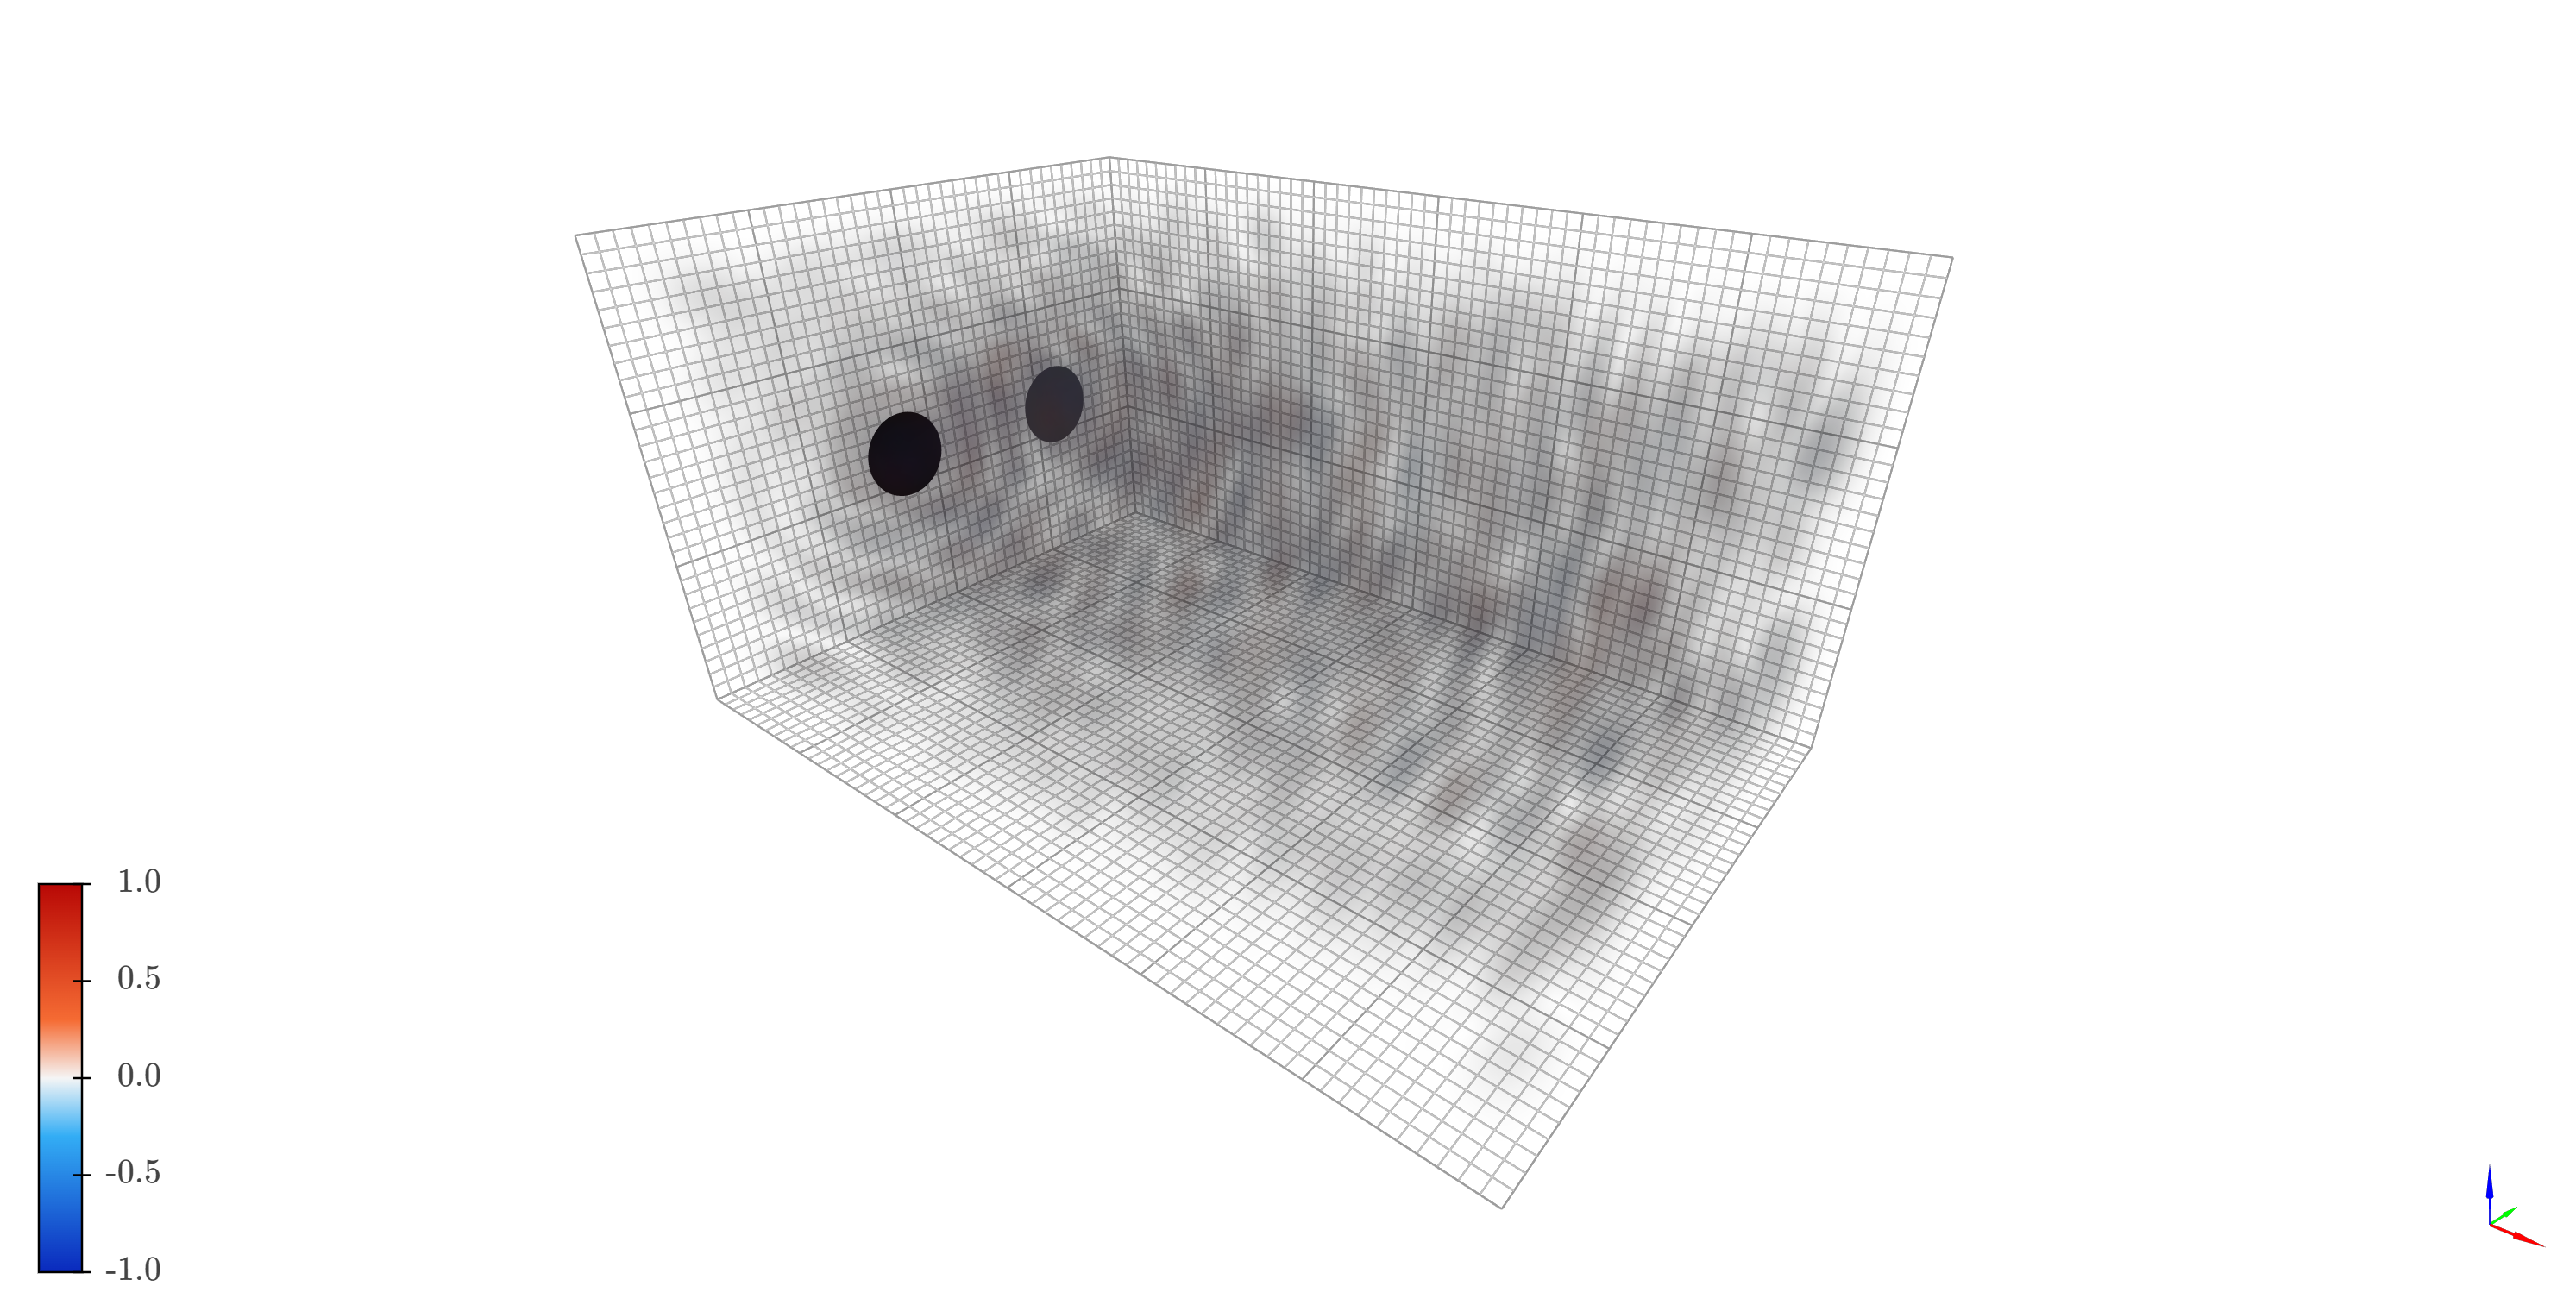